## Topic: LLM Based X post Generator Iterative Workflow

In [ ]:
""" 
Example 1: Tweet Post Generation
──────────────────────────────────────────────

Demonstrates:
    - 1. Generate LLM:
        - user topic --> LLM ---> response
            - here, llm response : Generate a Tweet
    
    - 2. Evaluate LLM:
        - Tweet ---> LLM ----> response
        - here,
            - response status either Approved or need improvement
            - if the response status is Approved then go the the end or terminate node.
            - Else or Evaluate LLM response Need Improvement then go the Optimize LLM
    
    - 3. Optimize LLM
        - Tweet ---> LLM ----> response
        - here,
            - response : Generate a optimize tweet 
            - then check the optimize tweet is best for posting by using the Evaluate LLM
            - then the same process until the tweet content is best or met a predefine threshold.



State:
  - topic -> str [User Provide a topic ]
  
  - tweet -> str [Generate LLm a Generate tweet]
  
  - approve - >  Literal["Approved", "Need Improvement"] -> here we need the structured response from the LLM.
 
  - threshold/max_iterations -> int [Predefined threshold or max iterations to stop the loop]
 
  - iteration -> int [Current iteration count]
  
  - history -> list[dict{iteration, tweet, approve}] [History of all the iterations]
 
"""

### 1. Import Necessary Libraries

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

c:\Users\kz\anaconda3\envs\GenAI\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


In [2]:
# Load environment variables from .env file
load_dotenv() 

True

### 2. Define Model
- We use the Same LLMs for different tasks
    - Generate generating tweets -> penai/gpt-oss-20b
    - Evaluating tweets -> penai/gpt-oss-20b
    - Optimizing tweets -> penai/gpt-oss-20b

- But the real work scenario, we must use different LLms for different tasks.

In [7]:
# Generator LLM for generating tweets
generator_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [8]:
# Evaluator LLM for evaluating tweets
evaluator_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [9]:
# Optimizer LLM for optimizing tweets
optimizer_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

### 3. Define the Structured Model
- Use when the Evaluate the tweet response


In [10]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["Approved", "needs_improvement"] = Field(..., description="Final Evaluation result of the tweet")
    feedback: str = Field(..., description="Constructive feedback for the tweet evaluation")



In [11]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

### 4. Define State
- We only focus on the X post Generator

  - topic -> str [User Provide a topic ]
  - tweet -> str [Generate LLm a Generate tweet]
  - evaluation - >  Literal["Approved", "Need Improvement"] 
  - feedback -> str 
  - threshold -> int [Predefined threshold or max iterations to stop the loop]
  - iteration -> int [Current iteration count]
  - history -> list[dict{iteration, tweet, approve}] [History of all the iterations]

In [12]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["Approved", "Needs_Improvement"]
    feedback: str
    threshold: int
    iteration: int
    history: list[dict]

### 6. Build the Nodes

In [13]:
# Generate_Tweet
# Purpose: Generate a tweet based on the provided topic using the generator LLM.
# Workflow: user topic -> generator LLM -> response (tweet)

def generate_tweet(state: TweetState) -> dict:
    """
    Generate a tweet based on the provided topic using the generator LLM.
    """
    # Define the prompt for the generator LLM
    messages = [
        SystemMessage(content= "Your are a funny and creative Twitter/X influencer. Your task is to generate a tweet based on the provided topic. The tweet should be engaging, humorous, and relevant to the topic."),

        HumanMessage(content= f"""Write a short, original and hilarious tweet on the topic: "{state['topic']} 
        
        Rules:
        - The tweet should be no more than 280 characters.
        - Do not use question-answer format.
        - Use observational humor, irony, sarcasm, or cultural references to make the tweet funny.
        - Think in memes logic, punchlines, or relatable situations that people can connect with.
        - Use simple and clear day to day english language that is easy to understand and relatable.
        - This is a creative task, so feel free to be imaginative and think outside the box.
        - This is version {state['iteration']+1} of the tweet generation. Please try to improve the previous version if possible.

        """)
    ]

    # Call the generator LLM to generate a tweet
    response = generator_llm(messages=messages)

    # Return the generated tweet and update the state
    return {
        "tweet": response.content
    }


In [14]:
# Evaluate_Tweet node
# Purpose: Evaluate the generated tweet using the evaluator LLM.
# Workflow: tweet -> evaluator LLM -> response (evaluation)

def evaluate_tweet(state: TweetState) -> dict:
    """
    Evaluate the generated tweet using the evaluator LLM.
    """
    # Define the prompt for the evaluator LLM
    messages = [
        SystemMessage(content= "You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format. The evaluation should be either 'Approved' or 'Needs Improvement' with feedback on how to improve it."),

        HumanMessage(content= f"""Evaluate the following tweet based on the topic: "{state['topic']}" and provide feedback on how to improve it if needed.

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality - Is this fresh, or have you seen it a hundred times before?  
        2. Humor - Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness - Is it short, sharp, and scroll-stopping?  
        4. Virality Potential - Would people retweet or share it?  
        5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 


        """)
    ]

    # Call the evaluator LLM to evaluate the tweet
    response = structured_evaluator_llm(messages=messages)

    # Partial update the state with the evaluation and feedback
    evaluation = response.evaluation
    
    feedback = response.feedback


    # Return the evaluation result and update the state
    return {
        "evaluation": evaluation,
        "feedback": feedback
    }



In [15]:
# optimize_tweet node
# Purpose: Optimize the tweet based on the feedback provided by the evaluator LLM.
# Workflow: tweet + feedback + topic -> optimizer LLM -> response (optimized tweet)

def optimize_tweet(state: TweetState) -> dict:
    """
    Optimize the tweet based on the feedback provided by the evaluator LLM.
    """
    # Define the prompt for the optimizer LLM
    messages = [
        SystemMessage(content= "You are a witty and creative Twitter influencer. Your task is to optimize a tweet based on the feedback provided by the evaluator LLM. The optimized tweet should be more engaging, humorous, and relevant to the topic."),

        HumanMessage(content= f"""Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.


        """)
    ]

    # Call the optimizer LLM to optimize the tweet
    response = optimizer_llm(messages=messages)
    iteration = state['iteration'] + 1

    # Return the optimized tweet and update the state
    return {
        "tweet": response.content,
        "iteration": iteration
    }

In [16]:
# route_evaluation
# Purpose: Route the evaluation result to the appropriate next step in the workflow.
# Workflow: evaluation -> if Approved -> END, else -> Optimize_Tweet

def route_evaluation(state: TweetState) -> dict:
    """
    Route the evaluation result to the appropriate next step in the workflow.
    """
    if state['evaluation'] == "Approved" or state['iteration'] >= state['threshold']:
        return {"Approved"}
    else:
        return {"needs_improvement"}

### 5. Create Graph

In [17]:
# Initialize the graph 
graph = StateGraph(TweetState)

# Define the Nodes
graph.add_node("Generate_Tweet", generate_tweet, name="Generate Tweet", description="Generate a tweet based on the provided topic using the generator LLM.")

graph.add_node("Evaluate_Tweet", evaluate_tweet, name="Evaluate Tweet", description="Evaluate the generated tweet using the evaluator LLM.")

graph.add_node("Optimize_Tweet", optimize_tweet, name="Optimize Tweet", description="Optimize the tweet based on the feedback from the evaluator LLM.")



# Define the Edges
graph.add_edge(START, "Generate_Tweet")

graph.add_edge("Generate_Tweet", "Evaluate_Tweet")


# Define the conditional edges based on the evaluation result
graph.add_conditional_edges("Evaluate_Tweet", route_evaluation,
    {
        "Approved": END,
        "needs_improvement": "Optimize_Tweet"
    }
)

graph.add_edge("Optimize_Tweet", "Evaluate_Tweet")

In [18]:
# compile the graph
workflow = graph.compile()


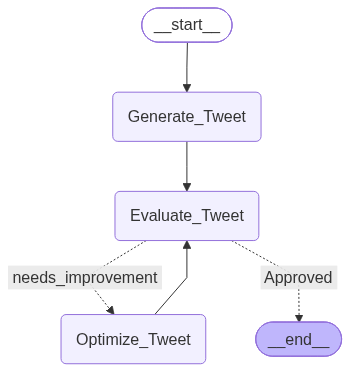

In [19]:
workflow

In [20]:
# Execute the workflow with an initial state
initial_state = {
    "topic": "The future of AI in everyday life",
    "iteration": 1,
    "threshold": 5,
}   


response = workflow.invoke(initial_state)

TypeError: 'ChatGroq' object is not callable

In [ ]:
# Execute the workflow with an initial state
initial_state = {
    "topic": "The future of AI in everyday life",
    "tweet": "",
    "evaluation": "",
    "feedback": "",
    "threshold": 3,  # Set a threshold for maximum iterations
    "iteration": 0,
    "history": []
}   

# Execute the workflow
for output in workflow.stream(initial_state):
    # Update the state with the output from the workflow
    initial_state.update(output)
    
    # Append the current state to the history
    initial_state['history'].append({
        "iteration": initial_state['iteration'],
        "tweet": initial_state['tweet'],
        "evaluation": initial_state['evaluation'],
        "feedback": initial_state['feedback']
    })
    
    # Print the current state for debugging
    print(f"Iteration {initial_state['iteration']}:")
    print(f"Tweet: {initial_state['tweet']}")
    print(f"Evaluation: {initial_state['evaluation']}")
    print(f"Feedback: {initial_state['feedback']}")
    print("-" * 50)
